In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
data=pd.read_csv('insurance.csv')

In [3]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


data.shape

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
data.describe() 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

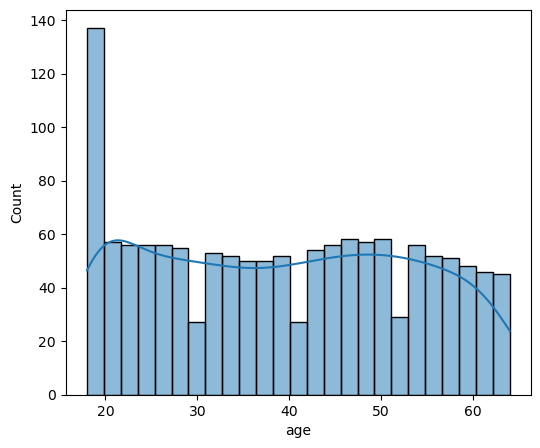

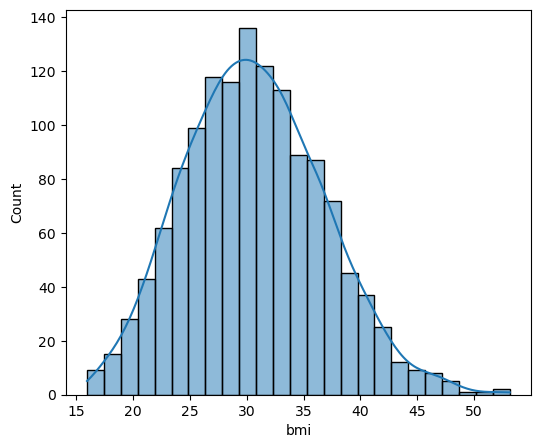

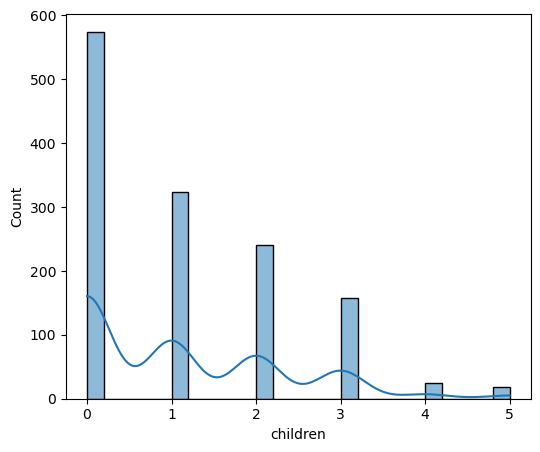

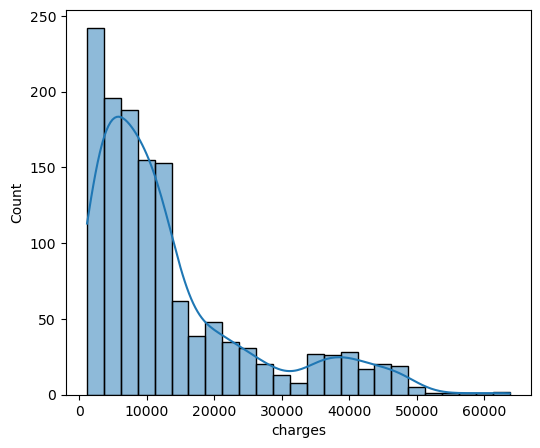

In [9]:
numeric_col=['age','bmi', 'children','charges']
for i in numeric_col:
    plt.figure(figsize=(6,5))
    sns.histplot(data[i],kde=True,bins=25)

<Axes: xlabel='children', ylabel='count'>

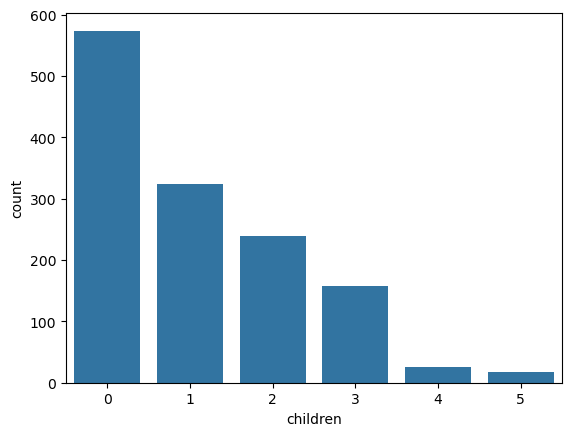

In [10]:
sns.countplot(x=data['children'])

<Axes: xlabel='sex', ylabel='count'>

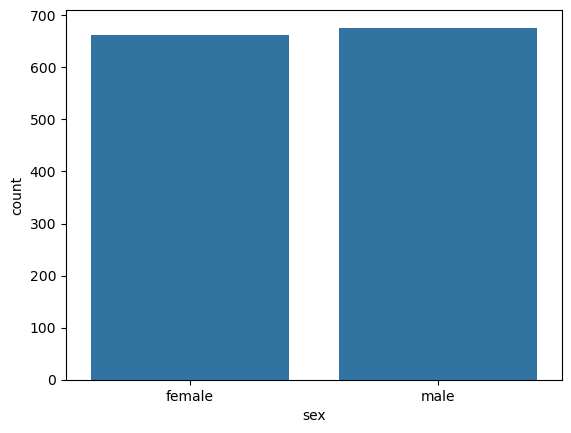

In [11]:
sns.countplot(x=data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

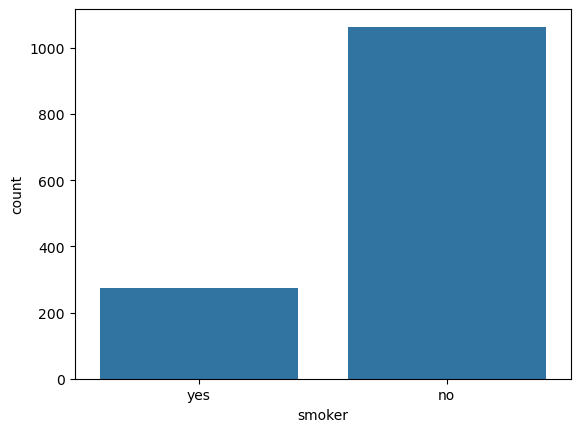

In [12]:
sns.countplot(x=data['smoker'])

<Axes: xlabel='region', ylabel='count'>

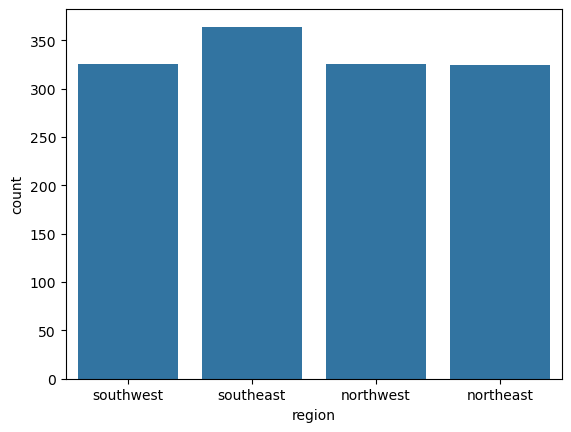

In [13]:
sns.countplot(x=data['region'])

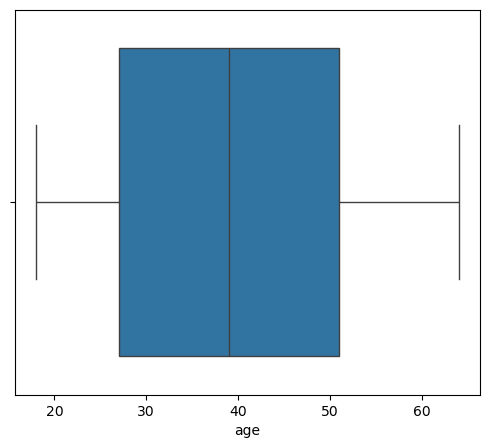

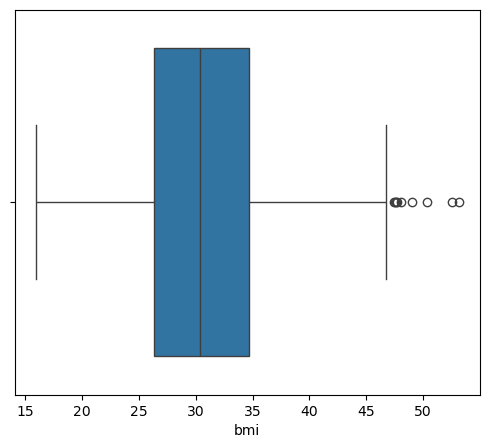

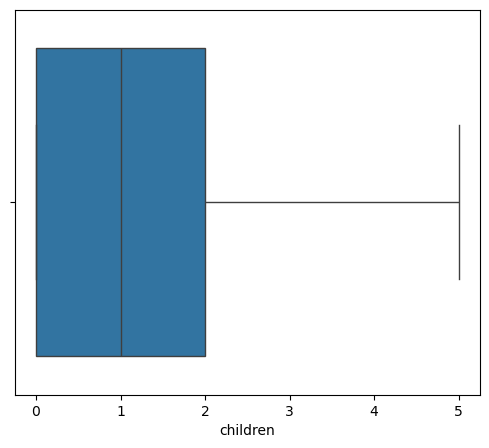

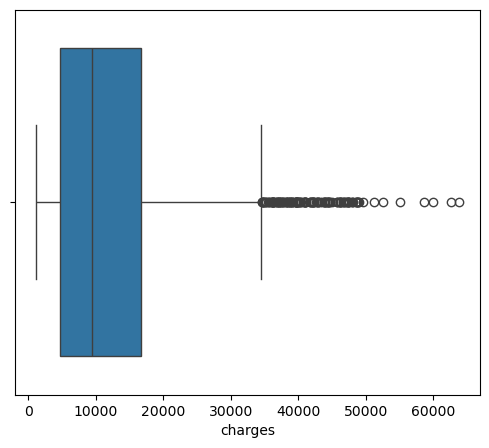

In [14]:
for i in numeric_col:
    plt.figure(figsize=(6,5))
    sns.boxplot(x=data[i])

<Axes: >

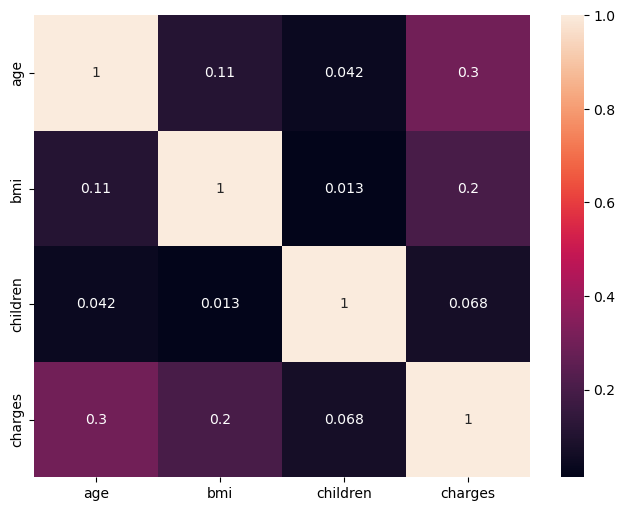

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True)
# heatmap only use for correlated

In [16]:
# DATA CLEANING AND PREPROCESSING

In [17]:
Data_cleaned=data.copy()

In [18]:
Data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
Data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [20]:
Data_cleaned.drop_duplicates(inplace=True)

In [21]:
Data_cleaned.shape

(1337, 7)

In [22]:
Data_cleaned.isnull().sum()
# find missing values in a row

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
Data_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [24]:
Data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [25]:
Data_cleaned['sex']=Data_cleaned['sex'].map({"male":0,"female":1})

In [26]:
Data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [27]:
Data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [28]:
Data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [29]:
Data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [30]:
Data_cleaned.rename(columns={'sex':'is_female', 'smoker':'is_smoker'},inplace=True)
# column name chane sex ae is female

In [31]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [32]:
Data_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [33]:
Data_cleaned=pd.get_dummies(Data_cleaned,columns=['region'],drop_first=True)

In [34]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,yes,16884.92400,False,False,True
1,18,0,33.770,1,no,1725.55230,False,True,False
2,28,0,33.000,3,no,4449.46200,False,True,False
3,33,0,22.705,0,no,21984.47061,True,False,False
4,32,0,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,10600.54830,True,False,False
1334,18,1,31.920,0,no,2205.98080,False,False,False
1335,18,1,36.850,0,no,1629.83350,False,True,False
1336,21,1,25.800,0,no,2007.94500,False,False,True


In [35]:
Data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [36]:
Data_cleaned['is_smoker']=Data_cleaned['is_smoker'].map({"no":0,"yes":1})

In [37]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [38]:
Data_cleaned=Data_cleaned.astype(int)

In [39]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [40]:
# Feature Engineering and extraction

In [41]:
Data_cleaned['bmi_cat']=pd.cut(Data_cleaned['bmi'],
bins=[0,18.5,24.9,29.9,float('inf')],
labels=['underweight','normal','overweight','obese'])

In [42]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cat
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [43]:
Data_cleaned['age_cat']=pd.cut(Data_cleaned['age'],
bins=[13,18,35,55,61,float('inf')],
labels=['young','Teenager','Adult','Middel_Aged','Senior'])

In [44]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cat,age_cat
0,19,1,27,0,1,16884,0,0,1,overweight,Teenager
1,18,0,33,1,0,1725,0,1,0,obese,young
2,28,0,33,3,0,4449,0,1,0,obese,Teenager
3,33,0,22,0,0,21984,1,0,0,normal,Teenager
4,32,0,28,0,0,3866,1,0,0,overweight,Teenager
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese,Adult
1334,18,1,31,0,0,2205,0,0,0,obese,young
1335,18,1,36,0,0,1629,0,1,0,obese,young
1336,21,1,25,0,0,2007,0,0,1,overweight,Teenager


In [45]:
Data_cleaned=pd.get_dummies(Data_cleaned,columns=['bmi_cat'],drop_first=True)

In [46]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,age_cat,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,19,1,27,0,1,16884,0,0,1,Teenager,False,True,False
1,18,0,33,1,0,1725,0,1,0,young,False,False,True
2,28,0,33,3,0,4449,0,1,0,Teenager,False,False,True
3,33,0,22,0,0,21984,1,0,0,Teenager,True,False,False
4,32,0,28,0,0,3866,1,0,0,Teenager,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Adult,False,False,True
1334,18,1,31,0,0,2205,0,0,0,young,False,False,True
1335,18,1,36,0,0,1629,0,1,0,young,False,False,True
1336,21,1,25,0,0,2007,0,0,1,Teenager,False,True,False


In [47]:
Data_cleaned=pd.get_dummies(Data_cleaned,columns=['age_cat'],drop_first=True)

In [48]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese,age_cat_Teenager,age_cat_Adult,age_cat_Middel_Aged,age_cat_Senior
0,19,1,27,0,1,16884,0,0,1,False,True,False,True,False,False,False
1,18,0,33,1,0,1725,0,1,0,False,False,True,False,False,False,False
2,28,0,33,3,0,4449,0,1,0,False,False,True,True,False,False,False
3,33,0,22,0,0,21984,1,0,0,True,False,False,True,False,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True,False,True,False,False
1334,18,1,31,0,0,2205,0,0,0,False,False,True,False,False,False,False
1335,18,1,36,0,0,1629,0,1,0,False,False,True,False,False,False,False
1336,21,1,25,0,0,2007,0,0,1,False,True,False,True,False,False,False


In [49]:
Data_cleaned=Data_cleaned.astype(int)

In [50]:
Data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese,age_cat_Teenager,age_cat_Adult,age_cat_Middel_Aged,age_cat_Senior
0,19,1,27,0,1,16884,0,0,1,0,1,0,1,0,0,0
1,18,0,33,1,0,1725,0,1,0,0,0,1,0,0,0,0
2,28,0,33,3,0,4449,0,1,0,0,0,1,1,0,0,0
3,33,0,22,0,0,21984,1,0,0,1,0,0,1,0,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1,0,1,0,0
1334,18,1,31,0,0,2205,0,0,0,0,0,1,0,0,0,0
1335,18,1,36,0,0,1629,0,1,0,0,0,1,0,0,0,0
1336,21,1,25,0,0,2007,0,0,1,0,1,0,1,0,0,0


In [51]:
# FEATURE SCALING

In [52]:
Data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese',
       'age_cat_Teenager', 'age_cat_Adult', 'age_cat_Middel_Aged',
       'age_cat_Senior'],
      dtype='object')

In [53]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
Data_cleaned[cols]=scaler.fit_transform(Data_cleaned[cols])

In [54]:
Data_cleaned[cols]

,age,bmi,children
0,-1.440418,-0.517949,-0.909234
1,-1.511647,0.462463,-0.079442
2,-0.799350,0.462463,1.580143
3,-0.443201,-1.334960,-0.909234
4,-0.514431,-0.354547,-0.909234
...,...,...,...
1333,0.767704,-0.027743,1.580143
1334,-1.511647,0.135659,-0.909234
1335,-1.511647,0.952670,-0.909234
1336,-1.297958,-0.844753,-0.909234


In [55]:
from scipy.stats import pearsonr
# pearson correlation calculation
selected_features=['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese',
       'age_cat_Teenager', 'age_cat_Adult', 'age_cat_Middel_Aged',
       'age_cat_Senior']
correlations={
    feature:pearsonr(Data_cleaned[feature],Data_cleaned['charges'])[0]
    for feature in selected_features
}
correlations_df=pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson correlations'])
correlations_df.sort_values(by='Pearson correlations',ascending=False)

,Feature,Pearson correlations
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,bmi_cat_obese,0.200348
2,bmi,0.196236
15,age_cat_Senior,0.142628
14,age_cat_Middel_Aged,0.134778
13,age_cat_Adult,0.103717
7,region_southeast,0.073577
3,children,0.067390


In [56]:
cat_features=['is_female', 'is_smoker','region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese',
       'age_cat_Teenager', 'age_cat_Adult', 'age_cat_Middel_Aged',
       'age_cat_Senior']

In [57]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

Data_cleaned['charges_bin'] = pd.qcut(
    Data_cleaned['charges'],
    q=4,
    labels=False
)

chi2_results = {}

for i in cat_features:
    
    contingency = pd.crosstab(
        Data_cleaned[i],
        Data_cleaned['charges_bin']
    )

    chi2_stats, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        'Reject Null (Keep Feature)'
        if p_val < alpha
        else 'Accept Null (Drop Feature)'
    )

    chi2_results[i] = {
        'chi2_statistic': chi2_stats,
        'p_value': p_val,
        'Decision': decision
    }
    chi2_df=pd.DataFrame(chi2_results).T
    chi2_df=chi2_df.sort_values(by='p_value')
    chi2_df


In [58]:
final_df=Data_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese',
       'age_cat_Teenager', 'age_cat_Adult', 'age_cat_Middel_Aged',
       'age_cat_Senior']]

In [59]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese,age_cat_Teenager,age_cat_Adult,age_cat_Middel_Aged,age_cat_Senior
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,1,0,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0,0,0,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,1,0,0,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,1,0,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1,0,1,0,0
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1,0,0,0,0
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1,0,0,0,0
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0,1,0,0,0


In [60]:
from sklearn.model_selection import train_test_split

In [63]:
x=final_df.drop('charges',axis=1)
y=final_df['charges']

In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_sized=0.33,random_state=42)

NameError: name 'y' is not defined